In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Lab Work

In [4]:
# Transaction Encoder
# apriori
# association_rules: generate association rukes frin frequent itemsets

In [3]:
data = pd.read_csv('Groceries data.csv')
data

,Member_number,Date,itemDescription,year,month,day,day_of_week
0,1808,2015-07-21,tropical fruit,2015,7,21,1
1,2552,2015-05-01,whole milk,2015,5,1,4
2,2300,2015-09-19,pip fruit,2015,9,19,5
3,1187,2015-12-12,other vegetables,2015,12,12,5
4,3037,2015-01-02,whole milk,2015,1,2,4
...,...,...,...,...,...,...,...
38760,4471,2014-08-10,sliced cheese,2014,8,10,6
38761,2022,2014-02-23,candy,2014,2,23,6
38762,1097,2014-04-16,cake bar,2014,4,16,2
38763,1510,2014-03-12,fruit/vegetable juice,2014,3,12,2


In [57]:
# group it by member no and date
basket = data.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()
transactions = basket['itemDescription'].tolist()
transactions[:5]

[['whole milk', 'pastry', 'salty snack'],
 ['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['soda', 'pickled vegetables'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles']]

In [58]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)
df

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14958,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
14959,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14960,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14961,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [59]:
# used apiori algo from mlxtend to find the item which are frequently in list
from mlxtend.frequent_patterns import apriori
frequent_itemsets = apriori(df, min_support=0.001, use_colnames=True)
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])

Total Frequent Itemsets: 750


In [60]:
#  making the association rule like support confidence life from the mlxtend like If people buy X, they’re likely to also buy Y.
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 0.81) & rules['consequents'].apply(lambda x: len(x) >= 0.91)]
print("Association Rules:", rules.shape[0])
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


Association Rules: 130


,antecedents,consequents,support,confidence,lift
0,(UHT-milk),(other vegetables),0.002139,0.100000,0.818993
1,(UHT-milk),(whole milk),0.002540,0.118750,0.751949
2,(beef),(whole milk),0.004678,0.137795,0.872548
3,(berries),(other vegetables),0.002673,0.122699,1.004899
4,(berries),(whole milk),0.002272,0.104294,0.660414
...,...,...,...,...,...
125,"(whole milk, sausage)",(soda),0.001069,0.119403,1.229612
126,"(soda, sausage)",(whole milk),0.001069,0.179775,1.138374
127,"(whole milk, yogurt)",(sausage),0.001470,0.131737,2.182917
128,"(whole milk, sausage)",(yogurt),0.001470,0.164179,1.911760


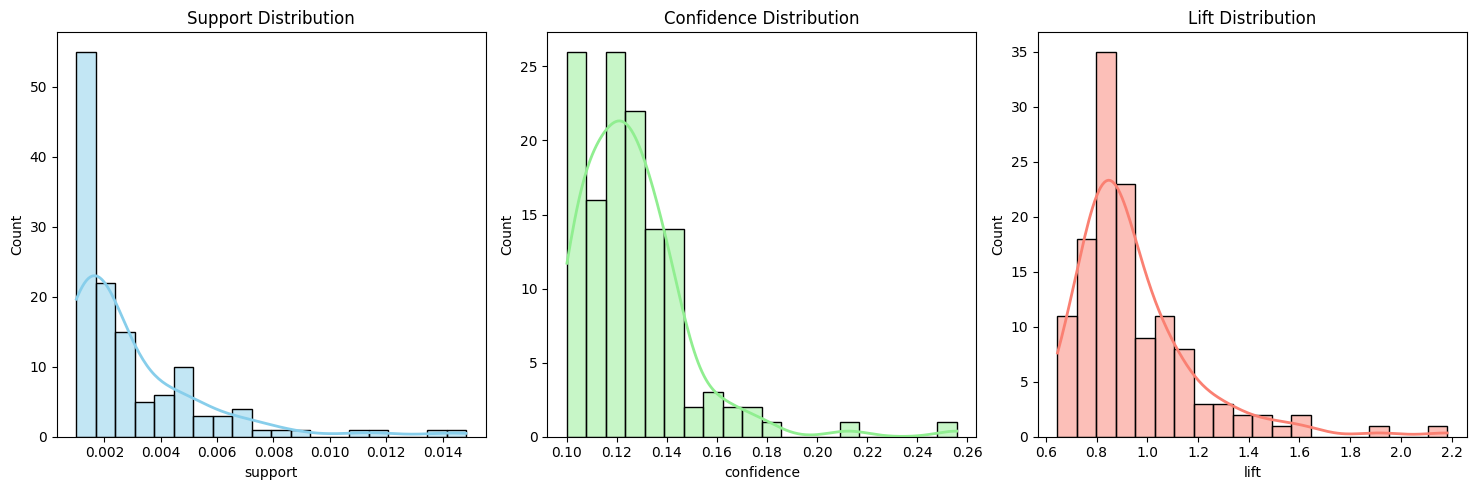

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rules['support'], bins=20, kde=True, line_kws={'color': 'black', 'linewidth': 2}, color='skyblue', ax=axes[0])
axes[0].set_title('Support Distribution')

sns.histplot(rules['confidence'], bins=20, kde=True, line_kws={'color': 'black', 'linewidth': 2}, color='lightgreen', ax=axes[1])
axes[1].set_title('Confidence Distribution')

sns.histplot(rules['lift'], bins=20, kde=True, line_kws={'color': 'black', 'linewidth': 2}, color='salmon', ax=axes[2])
axes[2].set_title('Lift Distribution')

plt.tight_layout()
plt.show()

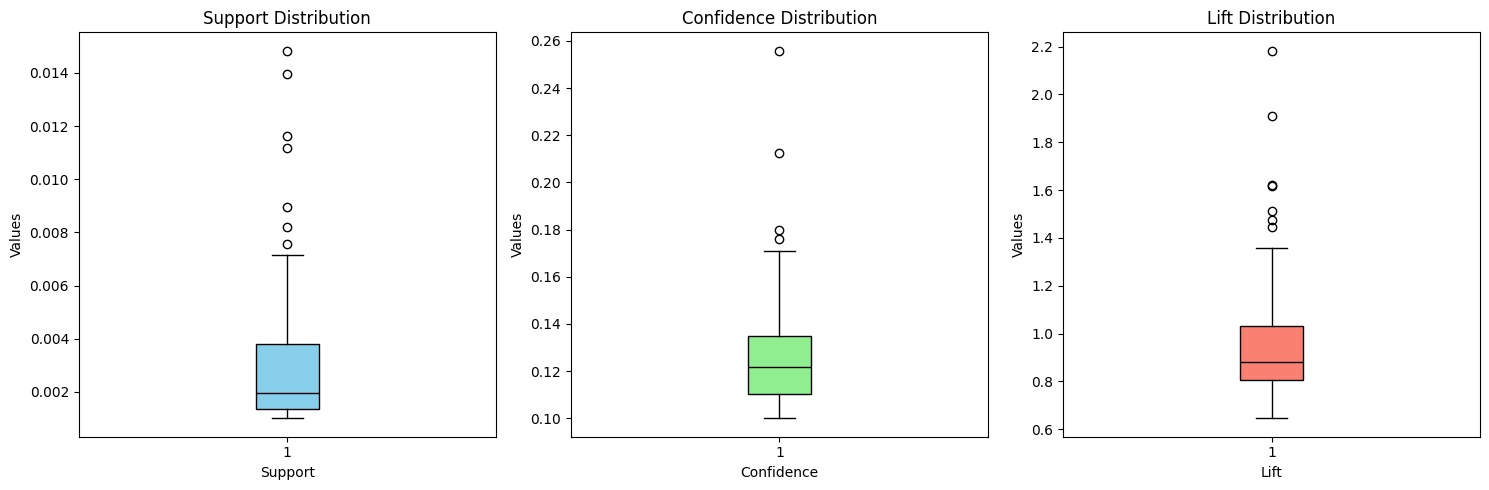

In [62]:
import matplotlib.pyplot as plt

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

boxprops = dict(facecolor='skyblue', color='black')
medianprops = dict(color='black')
whiskerprops = dict(color='black')

axes[0].boxplot(rules['support'], patch_artist=True, boxprops=boxprops, medianprops=medianprops, whiskerprops=whiskerprops)
axes[0].set_title('Support Distribution')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Values')

boxprops = dict(facecolor='lightgreen', color='black')
axes[1].boxplot(rules['confidence'], patch_artist=True, boxprops=boxprops, medianprops=medianprops, whiskerprops=whiskerprops)
axes[1].set_title('Confidence Distribution')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Values')

boxprops = dict(facecolor='salmon', color='black')
axes[2].boxplot(rules['lift'], patch_artist=True, boxprops=boxprops, medianprops=medianprops, whiskerprops=whiskerprops)
axes[2].set_title('Lift Distribution')
axes[2].set_xlabel('Lift')
axes[2].set_ylabel('Values')


plt.tight_layout()
plt.show()

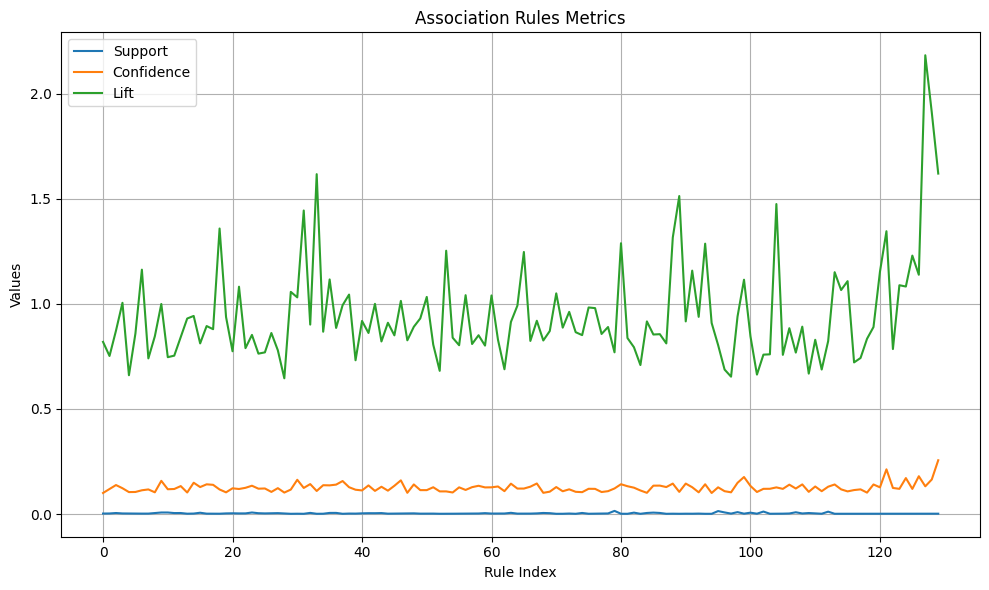

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(rules.index, rules['support'], label='Support')
plt.plot(rules.index, rules['confidence'], label='Confidence')
plt.plot(rules.index, rules['lift'], label='Lift')

plt.title('Association Rules Metrics')
plt.xlabel('Rule Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

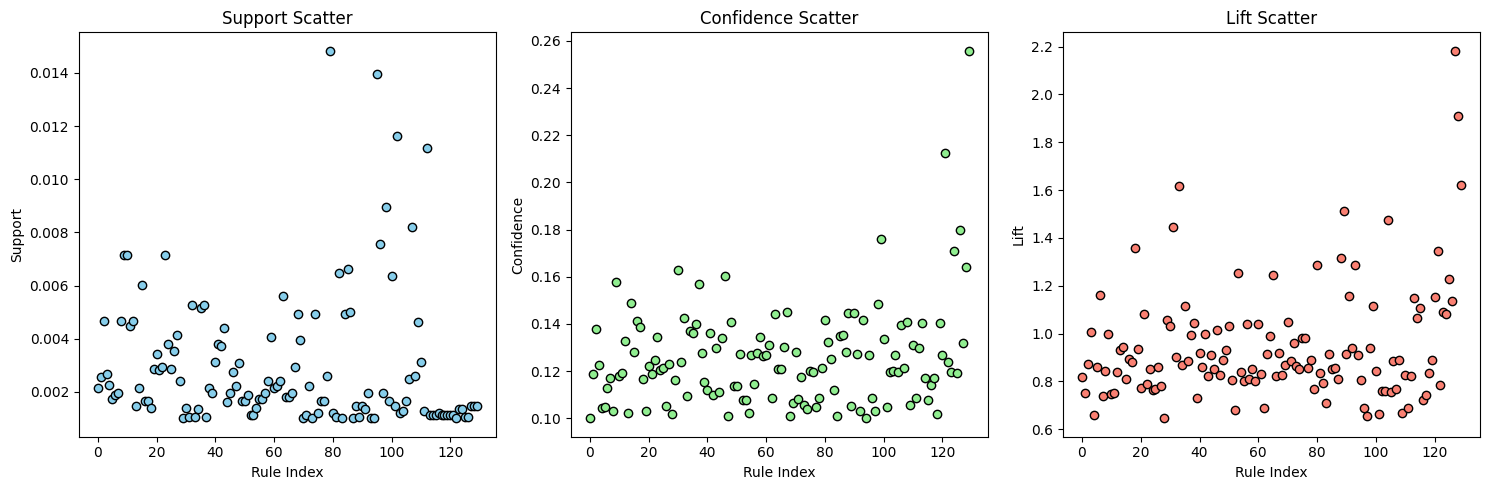

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(rules.index, rules['support'], color='skyblue', edgecolor='black')
axes[0].set_title('Support Scatter')
axes[0].set_xlabel('Rule Index')
axes[0].set_ylabel('Support')

axes[1].scatter(rules.index, rules['confidence'], color='lightgreen', edgecolor='black')
axes[1].set_title('Confidence Scatter')
axes[1].set_xlabel('Rule Index')
axes[1].set_ylabel('Confidence')

axes[2].scatter(rules.index, rules['lift'], color='salmon', edgecolor='black')
axes[2].set_title('Lift Scatter')
axes[2].set_xlabel('Rule Index')
axes[2].set_ylabel('Lift')

plt.tight_layout()
plt.show()


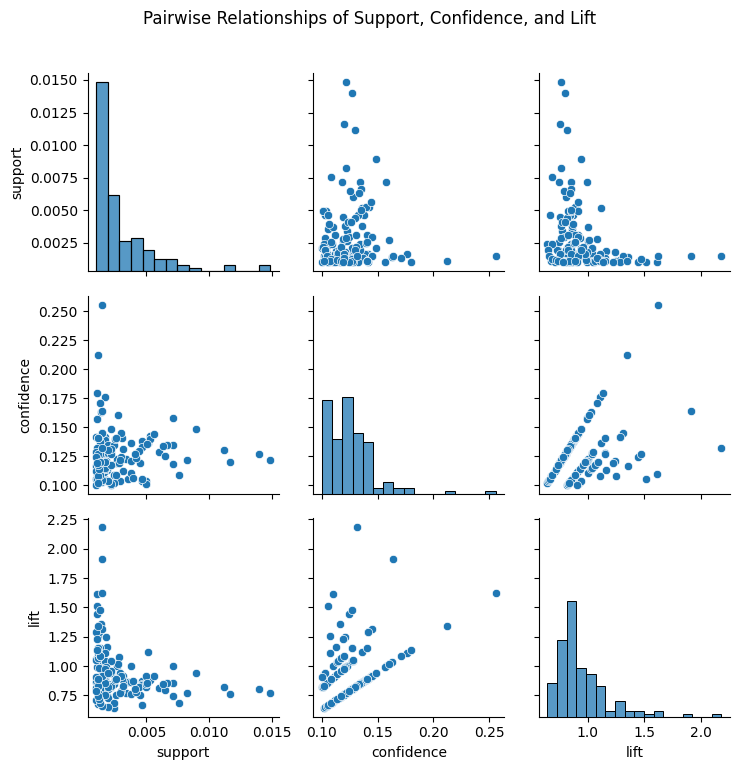

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(rules[['support', 'confidence', 'lift']])
plt.suptitle('Pairwise Relationships of Support, Confidence, and Lift', y=1.02)
plt.tight_layout()
plt.show()

            confidence      lift   support
confidence    1.000000  0.289320  0.164545
lift          0.289320  1.000000  0.035866
support       0.164545  0.035866  1.000000


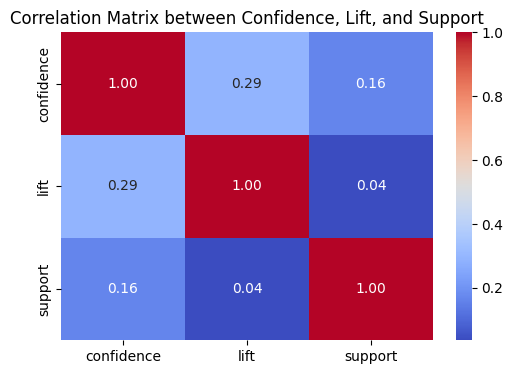

In [50]:
metrics = rules[['confidence', 'lift', 'support']]
corr_matrix = metrics.corr()
print(corr_matrix)
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix between Confidence, Lift, and Support")
plt.show()


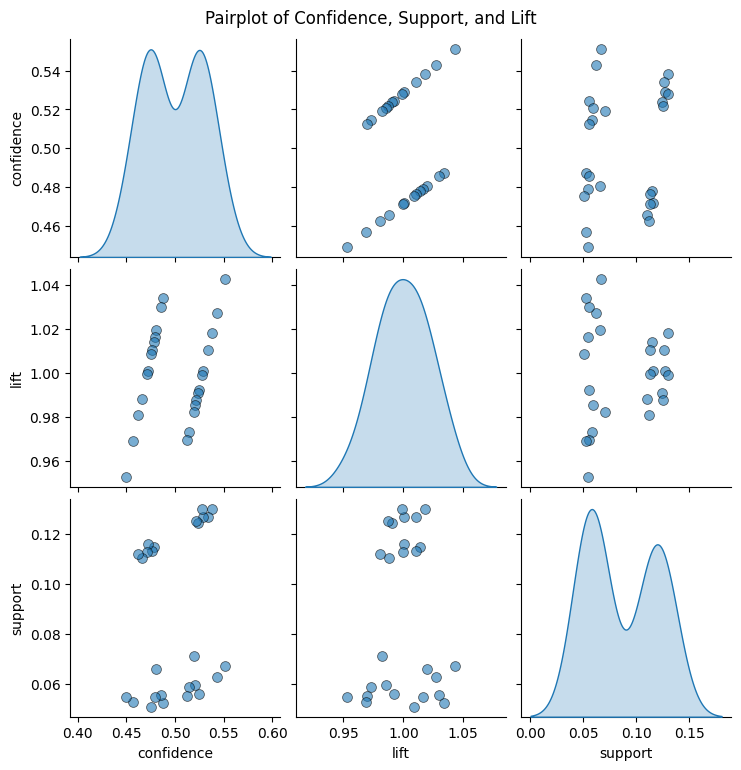

In [51]:
sns.pairplot(metrics, diag_kind='kde', plot_kws={'alpha':0.6, 's':50, 'edgecolor':'k'})
plt.suptitle("Pairplot of Confidence, Support, and Lift", y=1.02)
plt.show()


C:\Users\Kishan Pawar\AppData\Local\Temp\ipykernel_18892\2738107625.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='confidence_bin', data=rules, palette='viridis')


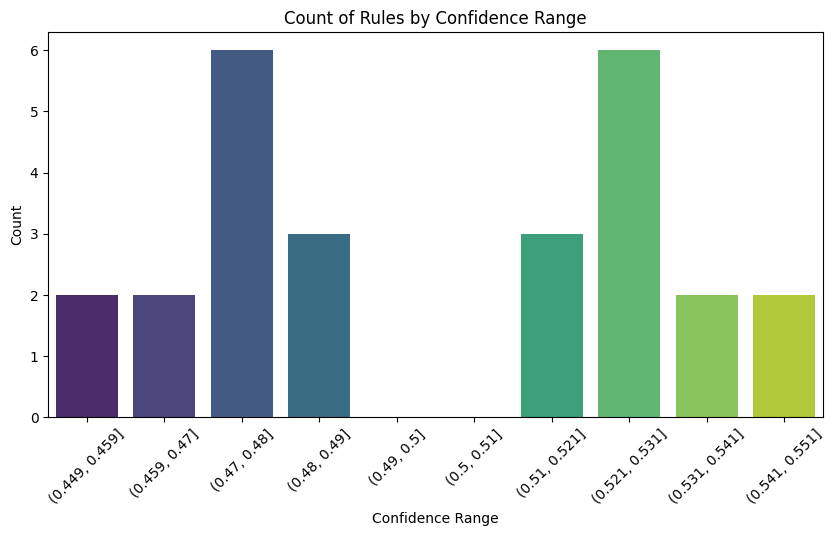

In [52]:
rules['confidence_bin'] = pd.cut(rules['confidence'], bins=10)
plt.figure(figsize=(10,5))
sns.countplot(x='confidence_bin', data=rules, palette='viridis')
plt.xticks(rotation=45)
plt.title("Count of Rules by Confidence Range")
plt.xlabel("Confidence Range")
plt.ylabel("Count")
plt.show()


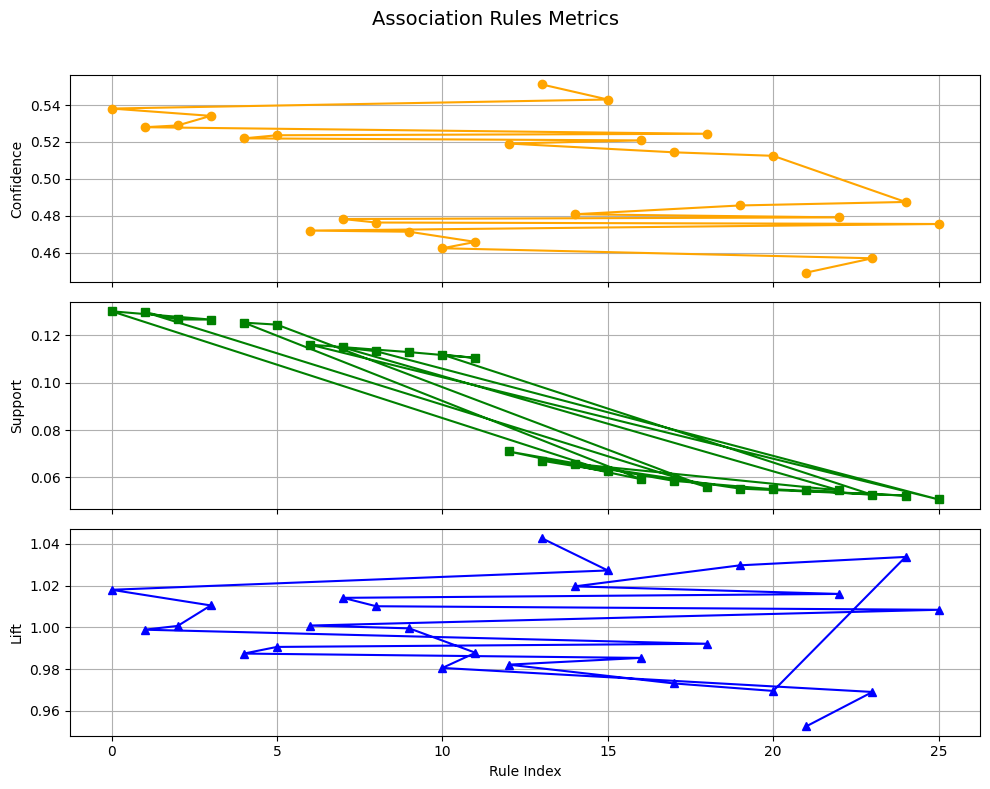

In [53]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(rules.index, rules['confidence'], marker='o', color='orange')
axes[0].set_ylabel("Confidence")
axes[0].grid(True)
axes[1].plot(rules.index, rules['support'], marker='s', color='green')
axes[1].set_ylabel("Support")
axes[1].grid(True)

# Lift
axes[2].plot(rules.index, rules['lift'], marker='^', color='blue')
axes[2].set_ylabel("Lift")
axes[2].set_xlabel("Rule Index")
axes[2].grid(True)

fig.suptitle("Association Rules Metrics", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
